# CreditSense EDA Starter

Use this notebook to produce the visuals and commentary for the report's Data Exploration & Preprocessing section.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from creditsense.features import add_engineered_features, build_data_profile

sns.set_theme(style='whitegrid')

In [2]:
train_df = pd.read_csv(PROJECT_ROOT / 'credit_train.csv')
test_df = pd.read_csv(PROJECT_ROOT / 'credit_test.csv')

train_df.shape, test_df.shape

((35000, 57), (15000, 55))

In [3]:
profile = build_data_profile(train_df.drop(columns=['RiskTier', 'InterestRate']))
pd.Series(profile['missing_counts']).head(15)

StudentLoanOutstandingBalance    20993
CollateralType                   19271
CollateralValue                  19124
MortgageOutstandingBalance       15813
PropertyValue                    15767
InvestmentPortfolioValue         12270
VehicleValue                      9840
AutoLoanOutstandingBalance        9830
SecondaryMonthlyIncome            9825
EmploymentLengthYears             1771
TotalCreditLimit                  1384
RevolvingUtilizationRate          1379
CreditHistoryLengthMonths         1080
NumberOfPublicRecords             1038
NumberOfHardInquiries12Mo          713
dtype: int64

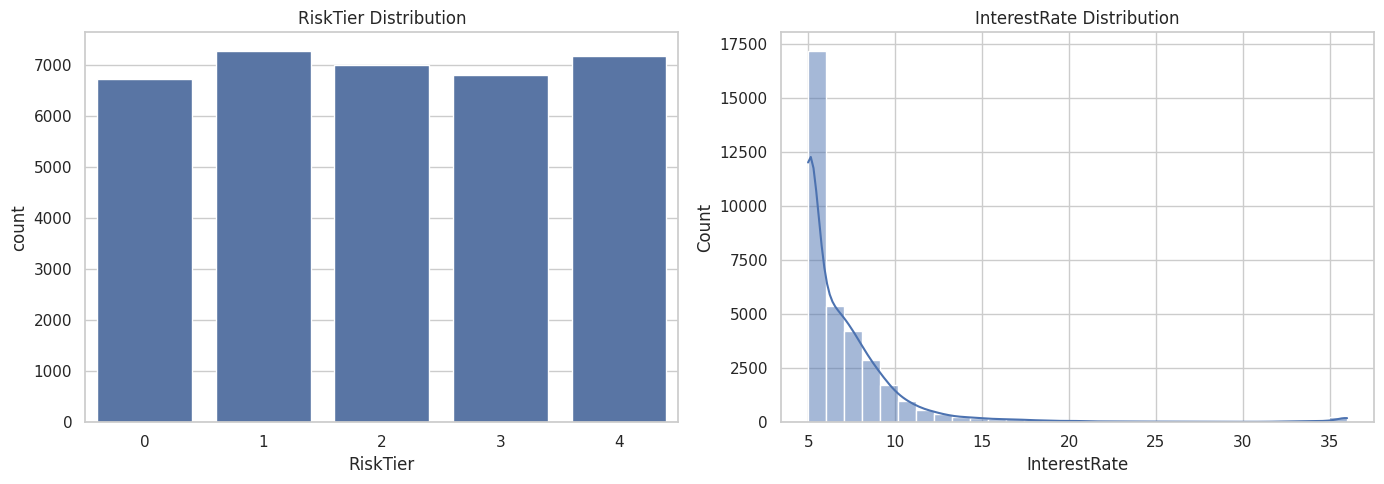

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=train_df, x='RiskTier', ax=axes[0])
axes[0].set_title('RiskTier Distribution')
sns.histplot(data=train_df, x='InterestRate', bins=30, kde=True, ax=axes[1])
axes[1].set_title('InterestRate Distribution')
plt.tight_layout()

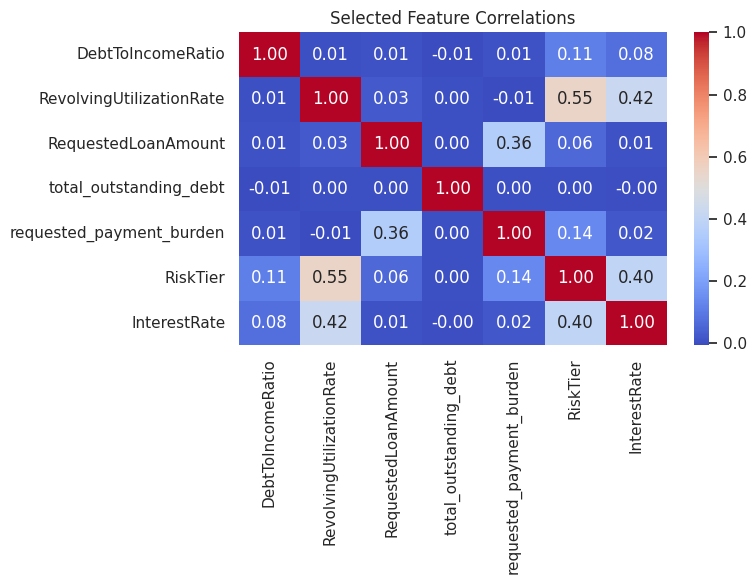

In [5]:
engineered = add_engineered_features(train_df.drop(columns=['RiskTier', 'InterestRate']))
selected = [
    'DebtToIncomeRatio',
    'RevolvingUtilizationRate',
    'RequestedLoanAmount',
    'total_outstanding_debt',
    'requested_payment_burden',
]
corr = pd.concat([engineered[selected], train_df[['RiskTier', 'InterestRate']]], axis=1).corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Selected Feature Correlations')
plt.tight_layout()

## Suggested next additions

- Add one missing-value visualization for the top sparse columns.
- Compare a few engineered features against both targets.
- Export your best plots for the report and slides.